# Laboratorio 2: Armado de un esquema de aprendizaje automático

En el laboratorio final se espera que puedan poner en práctica los conocimientos adquiridos en el curso, trabajando con un conjunto de datos de clasificación.

El objetivo es que se introduzcan en el desarrollo de un esquema para hacer tareas de aprendizaje automático: selección de un modelo, ajuste de hiperparámetros y evaluación.

El conjunto de datos a utilizar está en `./data/loan_data.csv`. Si abren el archivo verán que al principio (las líneas que empiezan con `#`) describen el conjunto de datos y sus atributos (incluyendo el atributo de etiqueta o clase).

Se espera que hagan uso de las herramientas vistas en el curso. Se espera que hagan uso especialmente de las herramientas brindadas por `scikit-learn`.

In [ ]:
import numpy as np
import pandas as pd

# TODO: Agregar las librerías que hagan falta
from sklearn.model_selection import train_test_split

## Carga de datos y división en entrenamiento y evaluación

La celda siguiente se encarga de la carga de datos (haciendo uso de pandas). Estos serán los que se trabajarán en el resto del laboratorio.

In [ ]:
#dataset = pd.read_csv("./data/loan_data.csv", comment="#")
dataset = pd.read_csv("https://raw.githubusercontent.com/DiploDatos/IntroduccionAprendizajeAutomatico/master/data/loan_data.csv", comment="#")


# División entre instancias y etiquetas
X, y = dataset.iloc[:, 1:], dataset.TARGET

# división entre entrenamiento y evaluación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


Documentación:

- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

## Ejercicio 1: Descripción de los Datos y la Tarea

Responder las siguientes preguntas:

1. ¿De qué se trata el conjunto de datos?
2. ¿Cuál es la variable objetivo que hay que predecir? ¿Qué significado tiene?
3. ¿Qué información (atributos) hay disponible para hacer la predicción?
4. ¿Qué atributos imagina ud. que son los más determinantes para la predicción?

1. El conjunto de datos HMEQ (por sus siglas en inglés, "Home Equity dataset") contiene información sobre 5960 préstamos con garantía hipotecaria (home equity loans). Un banco quiere utilizar estos datos con el fin de automatizar el proceso de toma de decisiones para la aprobación de líneas de crédito. Para ello, seguirán las recomendaciones de la Ley de Igualdad de Oportunidades de Crédito (Equal Credit Opportunity Act) para crear un modelo de puntuación que sea empíricamente fundamentado y estadísticamente sólido.

2. La variable objetivo a predecir es la columna "TARGET" que es una variable binaria que indica si un solicitante cumplió o no con el pago del préstamo. Esta variable toma como valor 1 si el cliente incumplió con el prestamo y 0 si este fue reembolsado.

3. Para cada cliente se tomó información sobre los siguientes atributos, acompañados por el valor que toma el "TARGET":

   - "LOAN": Monto de préstamo solicitado.

   - "MORTDUE": Monto adeudado de la hipoteca existente.

   - "VALUE": Valor de la propiedad actual.

   - "YOJ": Años en el trabajo actual.

   - "DEROG": Número de informes despectivos importantes.
  
   - "DELINQ": Número de líneas de crédito morosas.
  
   - "CLAGE": Edad de la linea comercial más antigua en meses.
  
   - "NINQ": Número de líneas de crédito recientes.
  
   - "CLNO": Número de lineas de crédito.
  
   - "DEBTINC": Relación deuda-ingresos.

4. A priori, nosotros creemos que un atributo importante para la predicción puede ser el "YOJ", ya que una persona con una gran cantidad de años en un mismo trabajo refleja estabilidad económica lo que puede permitirle a la persona pagar el préstamo. Algo similar podemos pensar sobre la variable "DEBTINC". Por otro lado, tanto "DEROG" como "DELINQ" pueden indicar el historial del solicitante, lo que permite evaluar su confiabilidad para pagar el préstamo.

## Ejercicio 2: Predicción con Modelos Lineales

En este ejercicio se entrenarán modelos lineales de clasificación para predecir la variable objetivo.

Para ello, deberán utilizar la clase SGDClassifier de scikit-learn.

Documentación:
- https://scikit-learn.org/stable/modules/sgd.html
- https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html


### Ejercicio 2.1: SGDClassifier con hiperparámetros por defecto

Entrenar y evaluar el clasificador SGDClassifier usando los valores por omisión de scikit-learn para todos los parámetros. Únicamente **fijar la semilla aleatoria** para hacer repetible el experimento.

Evaluar sobre el conjunto de **entrenamiento** y sobre el conjunto de **evaluación**, reportando:
- Accuracy
- Precision
- Recall
- F1
- matriz de confusión

Primero hacemos una exploración de los datos, con el fin de ver si hay valores faltantes (y analizar si los podemos imputar) y de escalar los datos ya que el clasificador suele ser sensible a las escalas grandes.

In [ ]:
# Primero veamos si hay valores faltantes para ver si hay que imputar algunos datos
print(f"Total de valores faltantes en los atributos: {X.isnull().sum().sum()}")
print(f"Total de valores faltantes en el target: {y.isnull().sum().sum()}")

Total de valores faltantes en los atributos: 0
Total de valores faltantes en el target: 0


Como no hay valores a imputar, simplemente escalamos los datos antes de crear el modelo, entrenarlo y luego evaluar los datos de testeo.

In [ ]:
# Escalamos los datos
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Importamos el clasificador
from sklearn.linear_model import SGDClassifier

# Instanciamos el modelo con semilla fijada a 0 y el resto de los valores por omisión
model_SGD = SGDClassifier(random_state=0)

# Entrenamos el modelo con los datos de entrenamiento
model_SGD.fit(X_train, y_train)

# Evaluamos el modelo sobre los datos (tanto de train como de test)
y_pred_train_SGD = model_SGD.predict(X_train)
y_pred_test_SGD = model_SGD.predict(X_test)

In [ ]:
# Calculamos las métricas correspondientes para cada conjunto de datos
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# accuracy
accuracy_train_SGD = accuracy_score(y_train, y_pred_train_SGD)
accuracy_test_SGD = accuracy_score(y_test, y_pred_test_SGD)
# precision
precision_train_SGD = precision_score(y_train, y_pred_train_SGD)
precision_test_SGD = precision_score(y_test, y_pred_test_SGD)
# recall
recall_train_SGD = recall_score(y_train, y_pred_train_SGD)
recall_test_SGD = recall_score(y_test, y_pred_test_SGD)
# f1
f1_train_SGD = f1_score(y_train, y_pred_train_SGD)
f1_test_SGD = f1_score(y_test, y_pred_test_SGD)
# Imprimimos
print(f"Train accuracy: {accuracy_train_SGD}")
print(f"Test accuracy: {accuracy_test_SGD}")
print(" ")
print(f"Train precision: {precision_train_SGD}")
print(f"Test precision: {precision_test_SGD}")
print(" ")
print(f"Train recall: {recall_train_SGD}")
print(f"Test recall: {recall_test_SGD}")
print(" ")
print(f"Train f1: {f1_train_SGD}")
print(f"Test f1: {f1_test_SGD}")

Train accuracy: 0.8732299393122049
Test accuracy: 0.8679245283018868
 
Train precision: 0.7142857142857143
Test precision: 0.6451612903225806
 
Train recall: 0.41832669322709165
Test recall: 0.3448275862068966
 
Train f1: 0.5276381909547738
Test f1: 0.449438202247191


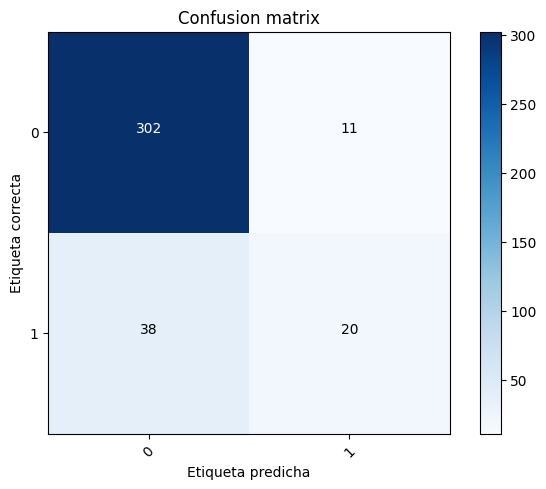

In [ ]:
# Hacemos la matriz de confusión sobre los datos de testeo
cm_SGD = confusion_matrix(y_test, y_pred_test_SGD)

# La graficamos
from utils import plot_confusion_matrix
plot_confusion_matrix(cm_SGD, [0, 1])

### Ejercicio 2.2: Ajuste de Hiperparámetros

Seleccionar valores para los hiperparámetros principales del SGDClassifier. Como mínimo, probar diferentes funciones de loss, tasas de entrenamiento y tasas de regularización.

Para ello, usar grid-search y 5-fold cross-validation sobre el conjunto de entrenamiento para explorar muchas combinaciones posibles de valores.

Reportar accuracy promedio y varianza para todas las configuraciones.

Para la mejor configuración encontrada, evaluar sobre el conjunto de **entrenamiento** y sobre el conjunto de **evaluación**, reportando:
- Accuracy
- Precision
- Recall
- F1
- matriz de confusión

Documentación:
- https://scikit-learn.org/stable/modules/grid_search.html
- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

Probemos diferentes valores de los hiperparámetros para encontrar la configuración con mejor rendimiento. Con este fin, vamos a ajustar los hiperparámetros: `loss` (función de pérdida), `learning rate` (tasa de aprendizaje), `alpha` (tasa de regularización), `eta0` (tasa de aprendizaje inicial), `class_weight` (ponderación de las clases).

Para esto, podemos armar un diccionario con los distintos hiperparámetros a probar y luego usar `RandomizedSearchCV` para realizar una busqueda aleatoria de los hiperparámetros, optimizada con validación cruzada.

In [ ]:
# Comenzamos creando el diccionario con los parámetros
from scipy.stats import loguniform

param_dist_SGD = {
    'loss': ['hinge', 'log_loss', 'modified_huber'],
    'alpha': loguniform(1e-4, 1e2),
    'learning_rate': ['constant', 'optimal', 'invscaling', 'adaptive'],
    'eta0': loguniform(1e-4, 1.0),
    'class_weight': [None, 'balanced'],
}


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Instanciamos el modelo con semilla fijada a 0 y el resto de los valores por omisión
model_SGD = SGDClassifier(random_state=0)

# Instanciamos la busqueda de parámetros
cv_SGD = RandomizedSearchCV(
    model_SGD,
    param_dist_SGD,
    n_iter=100,
    cv=5,
    #scoring='f1',
    random_state=0
)

# Entrenamos con los datos de entrenamiento
cv_SGD.fit(X_train, y_train);

In [ ]:
# Hacemos un DataFrame con los resultados para los intentos
cv_SGD_results = pd.DataFrame(cv_SGD.cv_results_)

# Mostrar accuracy media y desviación estándar

cv_SGD_results[[
    'param_loss',
    'param_alpha',
    'param_learning_rate',
    'param_eta0',
    'param_class_weight',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]].sort_values(by='mean_test_score', ascending=False)

,param_loss,param_alpha,param_learning_rate,param_eta0,param_class_weight,mean_test_score,std_test_score,rank_test_score
25,hinge,0.003876,constant,0.022185,None,0.871217,0.013134,1
39,log_loss,0.000396,adaptive,0.071939,None,0.870539,0.011354,2
9,hinge,0.000791,adaptive,0.029359,None,0.869858,0.007567,3
57,hinge,0.000133,adaptive,0.336002,None,0.869185,0.006859,4
95,hinge,0.004630,adaptive,0.002008,None,0.869183,0.008106,5
...,...,...,...,...,...,...,...,...
86,log_loss,0.000215,optimal,0.008948,balanced,0.691125,0.068636,96
42,modified_huber,0.000692,optimal,0.000189,balanced,0.688445,0.077478,97
31,hinge,0.307353,constant,0.727218,balanced,0.646069,0.132385,98
3,log_loss,0.256016,constant,0.220961,balanced,0.619686,0.036541,99


In [ ]:
# Vemos cual fue el mejor estimador y sus parámetros
best_model_SGD = cv_SGD.best_estimator_
best_model_SGD

SGDClassifier(alpha=np.float64(0.00387597516517953),
              eta0=np.float64(0.02218460698162246), learning_rate='constant',
              random_state=0)

In [ ]:
print(cv_SGD.best_params_)

{'alpha': np.float64(0.00387597516517953), 'class_weight': None, 'eta0': np.float64(0.02218460698162246), 'learning_rate': 'constant', 'loss': 'hinge'}


Ahora que ya tenemos el mejor modelo, valos a predecir las variables de evaluación con este modelo y a calcular las distintas métricas asociadas.

In [ ]:
# Predecimos tanto el conjunto de entrenamiento como el de testeo
y_pred_train_best_SGD = best_model_SGD.predict(X_train)
y_pred_test_best_SGD = best_model_SGD.predict(X_test)

# Calculamos las métricas
# accuracy
accuracy_train_best_SGD = accuracy_score(y_train, y_pred_train_best_SGD)
accuracy_test_best_SGD = accuracy_score(y_test, y_pred_test_best_SGD)
# precision
precision_train_best_SGD = precision_score(y_train, y_pred_train_best_SGD)
precision_test_best_SGD = precision_score(y_test, y_pred_test_best_SGD)
# recall
recall_train_best_SGD = recall_score(y_train, y_pred_train_best_SGD)
recall_test_best_SGD = recall_score(y_test, y_pred_test_best_SGD)
# f1
f1_train_best_SGD = f1_score(y_train, y_pred_train_best_SGD)
f1_test_best_SGD = f1_score(y_test, y_pred_test_best_SGD)
# Imprimimos
print(f"Train accuracy: {accuracy_train_best_SGD}")
print(f"Test accuracy: {accuracy_test_best_SGD}")
print(" ")
print(f"Train precision: {precision_train_best_SGD}")
print(f"Test precision: {precision_test_best_SGD}")
print(" ")
print(f"Train recall: {recall_train_best_SGD}")
print(f"Test recall: {recall_test_best_SGD}")
print(" ")
print(f"Train f1: {f1_train_best_SGD}")
print(f"Test f1: {f1_test_best_SGD}")

Train accuracy: 0.8712070128118679
Test accuracy: 0.8840970350404312
 
Train precision: 0.9285714285714286
Test precision: 0.9411764705882353
 
Train recall: 0.2589641434262948
Test recall: 0.27586206896551724
 
Train f1: 0.40498442367601245
Test f1: 0.4266666666666667


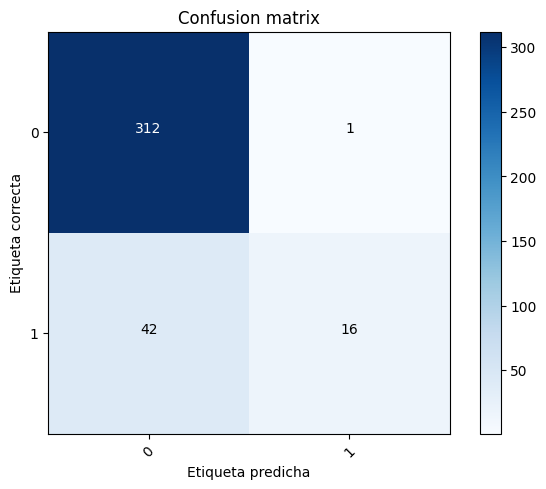

In [ ]:
# Hacemos la matriz de confusión sobre los datos de testeo
cm_best_SGD = confusion_matrix(y_test, y_pred_test_best_SGD)

# La graficamos
plot_confusion_matrix(cm_best_SGD, [0, 1])

## Ejercicio 3: Árboles de Decisión

En este ejercicio se entrenarán árboles de decisión para predecir la variable objetivo.

Para ello, deberán utilizar la clase DecisionTreeClassifier de scikit-learn.

Documentación:
- https://scikit-learn.org/stable/modules/tree.html
  - https://scikit-learn.org/stable/modules/tree.html#tips-on-practical-use
- https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
- https://scikit-learn.org/stable/auto_examples/tree/plot_unveil_tree_structure.html

### Ejercicio 3.1: DecisionTreeClassifier con hiperparámetros por defecto

Entrenar y evaluar el clasificador DecisionTreeClassifier usando los valores por omisión de scikit-learn para todos los parámetros. Únicamente **fijar la semilla aleatoria** para hacer repetible el experimento.

Evaluar sobre el conjunto de **entrenamiento** y sobre el conjunto de **evaluación**, reportando:
- Accuracy
- Precision
- Recall
- F1
- matriz de confusión


Al igual que antes, vamos a comenzar haciendo un `DecisionTreeClasifier` con los valores por omisión para todos los parámetros, fijando la semilla.

In [ ]:
# Importamos el arbol
from sklearn import tree

# Instanciamos el modelo con semilla fijada a 0 y el resto de los valores por omisión
model_tree = tree.DecisionTreeClassifier(random_state=0)

# Entrenamos el modelo con los datos de entrenamiento
model_tree.fit(X_train, y_train)

# Evaluamos el modelo sobre los datos (tanto de train como de test)
y_pred_train_tree = model_tree.predict(X_train)
y_pred_test_tree = model_tree.predict(X_test)

In [ ]:
# Calculamos las métricas
# accuracy
accuracy_train_tree = accuracy_score(y_train, y_pred_train_tree)
accuracy_test_tree = accuracy_score(y_test, y_pred_test_tree)
# precision
precision_train_tree = precision_score(y_train, y_pred_train_tree)
precision_test_tree = precision_score(y_test, y_pred_test_tree)
# recall
recall_train_tree = recall_score(y_train, y_pred_train_tree)
recall_test_tree = recall_score(y_test, y_pred_test_tree)
# f1
f1_train_tree = f1_score(y_train, y_pred_train_tree)
f1_test_tree = f1_score(y_test, y_pred_test_tree)
# Imprimimos
print(f"Train accuracy: {accuracy_train_tree}")
print(f"Test accuracy: {accuracy_test_tree}")
print(" ")
print(f"Train precision: {precision_train_tree}")
print(f"Test precision: {precision_test_tree}")
print(" ")
print(f"Train recall: {recall_train_tree}")
print(f"Test recall: {recall_test_tree}")
print(" ")
print(f"Train f1: {f1_train_tree}")
print(f"Test f1: {f1_test_tree}")

Train accuracy: 1.0
Test accuracy: 0.8814016172506739
 
Train precision: 1.0
Test precision: 0.6166666666666667
 
Train recall: 1.0
Test recall: 0.6379310344827587
 
Train f1: 1.0
Test f1: 0.6271186440677966


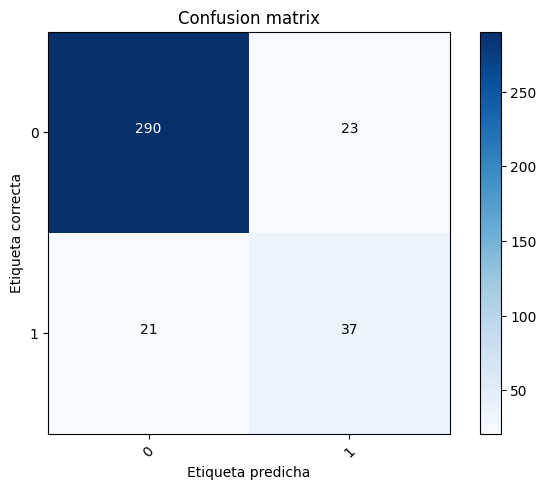

In [ ]:
# Hacemos la matriz de confusión sobre los datos de testeo
cm_tree = confusion_matrix(y_test, y_pred_test_tree)

# La graficamos
from utils import plot_confusion_matrix
plot_confusion_matrix(cm_tree, [0, 1])

### Ejercicio 3.2: Ajuste de Hiperparámetros

Seleccionar valores para los hiperparámetros principales del DecisionTreeClassifier. Como mínimo, probar diferentes criterios de partición (criterion), profundidad máxima del árbol (max_depth), y cantidad mínima de samples por hoja (min_samples_leaf).

Para ello, usar grid-search y 5-fold cross-validation sobre el conjunto de entrenamiento para explorar muchas combinaciones posibles de valores.

Reportar accuracy promedio y varianza para todas las configuraciones.

Para la mejor configuración encontrada, evaluar sobre el conjunto de **entrenamiento** y sobre el conjunto de **evaluación**, reportando:
- Accuracy
- Precision
- Recall
- F1
- matriz de confusión


Documentación:
- https://scikit-learn.org/stable/modules/grid_search.html
- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

Nuevamente, probaremos diferentes valores de los hiperparámetros para encontrar la configuración con mejor rendimiento. Los hiperparámetros a ajustar pueden ser: `criterion` (función de pérdida usada para medir la calidad de una separación), `splitter` (estrategia utilizada para separar cada nodo), `max_depth` (profundidad máxima del arbol, notar que tiende a sobreajustar), `min_samples_leaf` (mínimo de muestras en una hoja), `class_weight` (ponderación de las clases).

Con esto armemos un diccionario y usemos, al igual que antes, `RandomizedSearchCV`.

In [ ]:
# Comenzamos creando el diccionario con los parámetros
param_dist_tree = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': range(3, 20),
    'min_samples_leaf': [1, 2, 5, 10, 20],
    'class_weight': [None, 'balanced'],
}

In [ ]:
from sklearn.model_selection import GridSearchCV
# Instanciamos el modelo con semilla fijada a 0 y el resto de los valores por omisión
model_tree = tree.DecisionTreeClassifier(random_state=0)

# Instanciamos la busqueda de parámetros en grilla
cv_tree = GridSearchCV(model_tree, param_dist_tree, cv=5)

# Entrenamos con los datos de entrenamiento
cv_tree.fit(X_train, y_train);

In [ ]:
# Hacemos un DataFrame con los resultados para los intentos
cv_results_tree = pd.DataFrame(cv_tree.cv_results_)

# Mostrar accuracy media y desviación estándar

cv_results_tree[[
    'param_criterion',
    'param_splitter',
    'param_max_depth',
    'param_min_samples_leaf',
    'param_class_weight',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]].sort_values(by='mean_test_score', ascending=False)

,param_criterion,param_splitter,param_max_depth,param_min_samples_leaf,param_class_weight,mean_test_score,std_test_score,rank_test_score
81,gini,random,11,1,None,0.885379,0.013039,1
46,gini,best,7,10,None,0.883354,0.013152,2
36,gini,best,6,10,None,0.883342,0.005088,3
72,gini,best,10,2,None,0.882678,0.019672,4
121,gini,random,15,1,None,0.882655,0.011515,5
...,...,...,...,...,...,...,...,...
499,gini,random,18,20,balanced,0.691168,0.035857,673
509,gini,random,19,20,balanced,0.691168,0.035857,673
629,entropy,random,14,20,balanced,0.687155,0.025728,678
439,gini,random,12,20,balanced,0.680389,0.023606,679


In [ ]:
# Vemos cual fue el mejor estimador y sus parámetros
best_model_tree = cv_tree.best_estimator_
best_model_tree

DecisionTreeClassifier(max_depth=11, random_state=0, splitter='random')

In [ ]:
print(cv_tree.best_params_)

{'class_weight': None, 'criterion': 'gini', 'max_depth': 11, 'min_samples_leaf': 1, 'splitter': 'random'}


Ahora que ya tenemos el mejor modelo, valos a predecir las variables de evaluación con este modelo y a calcular las distintas métricas asociadas.

In [ ]:
# Predecimos tanto el conjunto de entrenamiento como el de testeo
y_pred_train_best_tree = best_model_tree.predict(X_train)
y_pred_test_best_tree = best_model_tree.predict(X_test)

# Calculamos las métricas
# accuracy
accuracy_train_best_tree = accuracy_score(y_train, y_pred_train_best_tree)
accuracy_test_best_tree = accuracy_score(y_test, y_pred_test_best_tree)
# precision
precision_train_best_tree = precision_score(y_train, y_pred_train_best_tree)
precision_test_best_tree = precision_score(y_test, y_pred_test_best_tree)
# recall
recall_train_best_tree = recall_score(y_train, y_pred_train_best_tree)
recall_test_best_tree = recall_score(y_test, y_pred_test_best_tree)
# f1
f1_train_best_tree = f1_score(y_train, y_pred_train_best_tree)
f1_test_best_tree = f1_score(y_test, y_pred_test_best_tree)
# Imprimimos
print(f"Train accuracy: {accuracy_train_best_tree}")
print(f"Test accuracy: {accuracy_test_best_tree}")
print(" ")
print(f"Train precision: {precision_train_best_tree}")
print(f"Test precision: {precision_test_best_tree}")
print(" ")
print(f"Train recall: {recall_train_best_tree}")
print(f"Test recall: {recall_test_best_tree}")
print(" ")
print(f"Train f1: {f1_train_best_tree}")
print(f"Test f1: {f1_test_best_tree}")

Train accuracy: 0.9325691166554282
Test accuracy: 0.9029649595687331
 
Train precision: 0.9748427672955975
Test precision: 0.8666666666666667
 
Train recall: 0.6175298804780877
Test recall: 0.4482758620689655
 
Train f1: 0.7560975609756098
Test f1: 0.5909090909090909


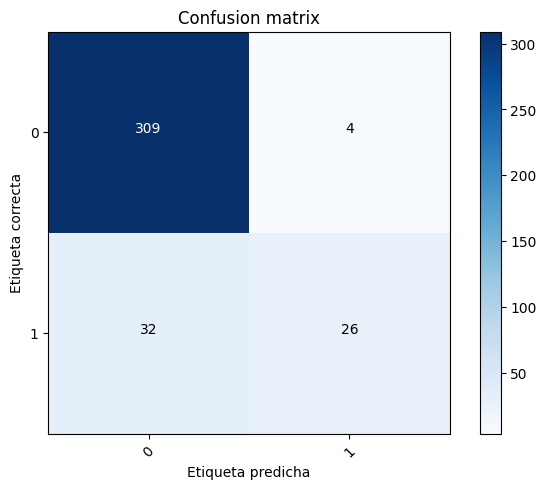

In [ ]:
# Hacemos la matriz de confusión sobre los datos de testeo
cm_best_tree = confusion_matrix(y_test, y_pred_test_best_tree)

# La graficamos
plot_confusion_matrix(cm_best_tree, [0, 1])

Podemos inspeccionar el arbol:

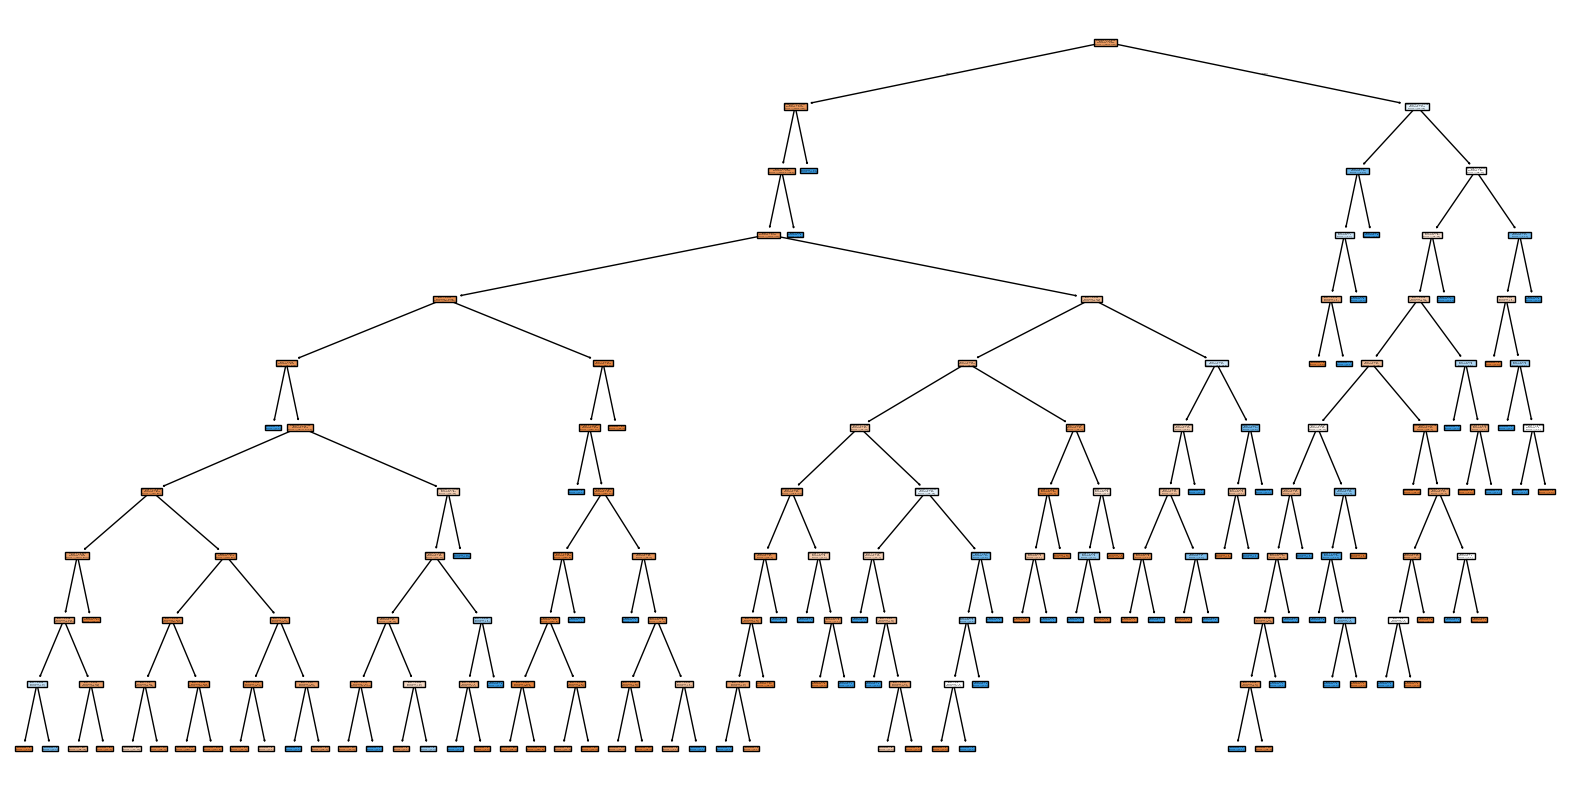

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(best_model_tree, filled=True, feature_names=X.columns)
plt.show()

Podemos ver en menor profundidad para ver cuales fueron las primeras segmentaciones de los datos.

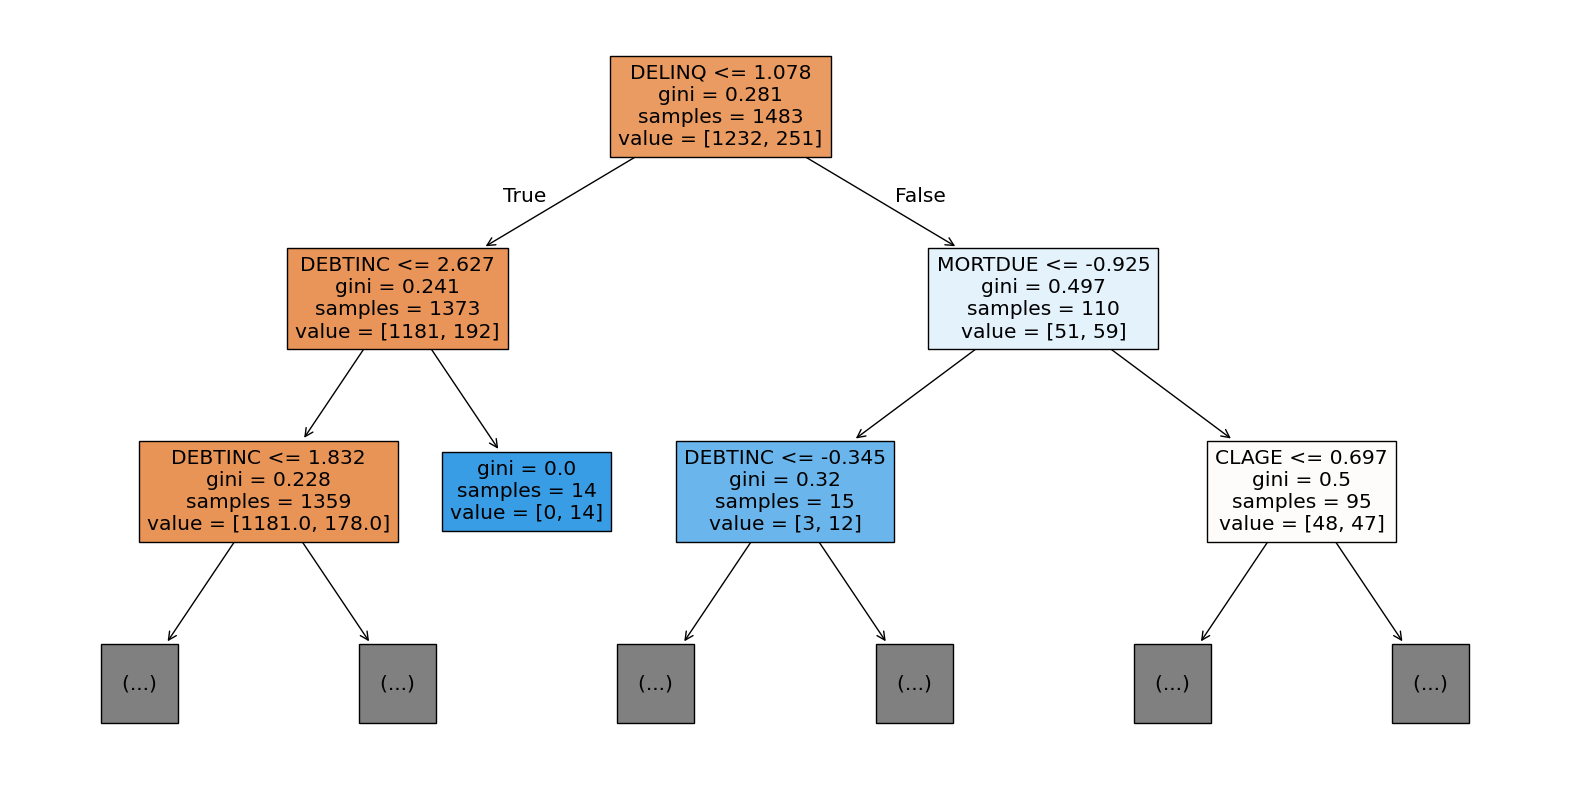

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(
    best_model_tree,
    filled=True,
    feature_names=X.columns,
    max_depth=2
)
plt.show()

Acá podemos observar que la primera segmentación se hace sobre `DELINQ` lo que nos indica que este parámetro es muy útil para poder predecir el valor de `TARGET` ya que permite hacer la separación más efectiva.

Luego, aparecen otras variables importantes como `DEBTINC` y `MORTDUE`, que también contribuyen significativamente a las decisiones del modelo.

Podemos analizar las métricas y graficarlas:

In [ ]:
# Creamos el DataFrame con las métricas
resultados_test = pd.DataFrame({
    'Modelo': [
        'SGD (default)',
        'SGD (best)',
        'Tree (default)',
        'Tree (best)'
    ],
    'Accuracy': [
        accuracy_test_SGD,
        accuracy_test_best_SGD,
        accuracy_test_tree,
        accuracy_test_best_tree
    ],
    'Precision': [
        precision_test_SGD,
        precision_test_best_SGD,
        precision_test_tree,
        precision_test_best_tree
    ],
    'Recall': [
        recall_test_SGD,
        recall_test_best_SGD,
        recall_test_tree,
        recall_test_best_tree
    ],
    'F1': [
        f1_test_SGD,
        f1_test_best_SGD,
        f1_test_tree,
        f1_test_best_tree
    ]
})

# Mostramos la tabla
resultados_test

,Modelo,Accuracy,Precision,Recall,F1
0,SGD (default),0.867925,0.645161,0.344828,0.449438
1,SGD (best),0.884097,0.941176,0.275862,0.426667
2,Tree (default),0.881402,0.616667,0.637931,0.627119
3,Tree (best),0.902965,0.866667,0.448276,0.590909


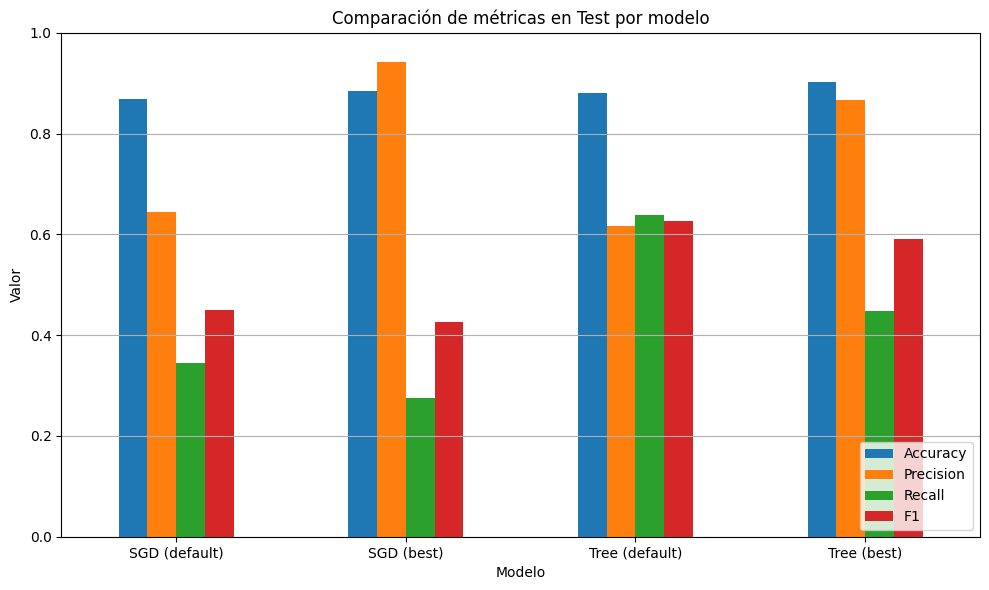

In [ ]:
# Graficamos
# Ponemos el índice como los nombres de los modelos
resultados_test.set_index('Modelo').plot(kind='bar', figsize=(10, 6))
plt.title("Comparación de métricas en Test por modelo")
plt.ylabel("Valor")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

Notamos que el modelo predice correctamente la mayoría de los casos con `TARGET`= 0 (clientes que cumplen con el préstamo), pero tiene más dificultad para identificar correctamente a los que tienen `TARGET`= 1 (clientes morosos).

Esto se refleja en una accuracy y precision relativamente altas, pero con un recall bajo y una f1 también limitada.

Este comportamiento se debe al desbalance de clases en el dataset: solo alrededor del 20% de los casos corresponden a clientes morosos.

Una posible mejora sería aplicar técnicas de remuestreo, como sobremuestreo de la clase minoritaria (por ejemplo, usando SMOTE).